# CSET485 – AI and Society
## Self-Learning Assignment #1 — Parts 1 & 2

| Field | Value |
|-------|-------|
| **Roll Number** | 0035 |
| **Dataset** | German Credit Data (UCI Statlog) |
| **Random Seed** | 35 (last 3 digits of 0035) |
| **Train / Test Split** | 70 % / 30 % |

---

### Table of Contents
0. Setup & Data Loading
1. Data Preprocessing
2. Part 1 — Build (OLS vs Logistic)
3. Part 2.1 — Simpson's Paradox Hunt
4. Part 2.2 — Omitted-Variable Bias
5. Part 2.3 — Adversarial Subset Construction
6. Part 2.4 — Fairness Trade-Off Analysis
7. Final Summary

---
## 0. Setup & Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import urllib.request

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

os.makedirs('outputs', exist_ok=True)

In [2]:
# Dataset: German Credit Data (roll number 0035 ends in 5 -> dataset for last digits 3, 4, 5)

col_names = [
    'status_checking', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings', 'employment_since', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installment_plans', 'housing', 'existing_credits',
    'job', 'people_liable', 'telephone', 'foreign_worker', 'class'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
local_path = 'german.data'

try:
    df_raw = pd.read_csv(url, sep=' ', header=None, names=col_names)
    print('Loaded from URL')
except Exception:
    if not os.path.exists(local_path):
        urllib.request.urlretrieve(url, local_path)
    df_raw = pd.read_csv(local_path, sep=' ', header=None, names=col_names)
    print('Loaded from local file')

print('Shape:', df_raw.shape)
df_raw.head(3)

Loaded from URL
Shape: (1000, 21)


,status_checking,duration,credit_history,purpose,credit_amount,savings,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1


### Quick look at the raw data

In [3]:
print('--- dtypes ---')
print(df_raw.dtypes)
print('\n--- Class balance (raw) ---')
vc = df_raw['class'].value_counts()
pct = df_raw['class'].value_counts(normalize=True).mul(100).round(2)
balance = pd.DataFrame({'count': vc, 'pct': pct})
balance.index.name = 'class (1=good, 2=bad)'
print(balance)

--- dtypes ---
status_checking            object
duration                    int64
credit_history             object
purpose                    object
credit_amount               int64
savings                    object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
class                       int64
dtype: object

--- Class balance (raw) ---
                       count   pct
class (1=good, 2=bad)             
1                        700  70.0
2                        300  30.0


---
## 1. Data Preprocessing

This section covers four preprocessing decisions:
1. **Missing values** - check counts per column
2. **Encoding** - create target and derived features, one-hot encode categoricals
3. **Outliers** - IQR rule on numeric columns, log transformation of credit_amount
4. **Scaling** - StandardScaler fitted on train only

### 1.1 Missing Values

In [4]:
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None -- no missing values found')

Missing values per column:
None -- no missing values found


**Decision:** The German Credit dataset has no missing values in any column. No imputation is needed.

### 1.2 Encoding

In [5]:
df = df_raw.copy()

df['approval'] = (df['class'] == 1).astype(int)

df['gender'] = 'male'
df.loc[df['personal_status_sex'] == 'A92', 'gender'] = 'female'

df['age_group'] = 'older'
df.loc[df['age'] < 25, 'age_group'] = 'young'

print('Approval distribution:')
print(df['approval'].value_counts())
print('\nGender distribution:')
print(df['gender'].value_counts())
print('\nAge group distribution:')
print(df['age_group'].value_counts())

Approval distribution:
approval
1    700
0    300
Name: count, dtype: int64

Gender distribution:
gender
male      690
female    310
Name: count, dtype: int64

Age group distribution:
age_group
older    851
young    149
Name: count, dtype: int64


In [6]:
cat_cols = [
    'status_checking', 'credit_history', 'purpose', 'savings',
    'employment_since', 'personal_status_sex', 'other_debtors',
    'property', 'other_installment_plans', 'housing', 'job',
    'telephone', 'foreign_worker', 'gender', 'age_group'
]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
df_encoded = df_encoded.drop(columns=['class'], errors='ignore')

print('Shape after encoding:', df_encoded.shape)
new_dummy_cols = [c for c in df_encoded.columns if c not in
                  ['duration','installment_rate','residence_since','age',
                   'existing_credits','people_liable','approval','credit_amount']]
print('\nDummy columns created (first 15):')
print(new_dummy_cols[:15])

Shape after encoding: (1000, 51)

Dummy columns created (first 15):
['status_checking_A12', 'status_checking_A13', 'status_checking_A14', 'credit_history_A31', 'credit_history_A32', 'credit_history_A33', 'credit_history_A34', 'purpose_A41', 'purpose_A410', 'purpose_A42', 'purpose_A43', 'purpose_A44', 'purpose_A45', 'purpose_A46', 'purpose_A48']


**Encoding decisions:**
- `approval` (target): 1 if class==1 (good credit), 0 if class==2 (bad credit)
- `gender`: 'female' if personal_status_sex == A92, else 'male'
- `age_group`: 'young' if age < 25, else 'older'
- All 15 categorical columns were one-hot encoded with drop_first=True to avoid the dummy variable trap.

### 1.3 Outliers and Transformations

In [7]:
outlier_cols = ['duration', 'credit_amount', 'age']

for col in outlier_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    print(f'{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, lower={lower:.1f}, upper={upper:.1f} -> outliers: {n_out}')

duration: Q1=12.0, Q3=24.0, IQR=12.0, lower=-6.0, upper=42.0 -> outliers: 70
credit_amount: Q1=1365.5, Q3=3972.2, IQR=2606.8, lower=-2544.6, upper=7882.4 -> outliers: 72
age: Q1=27.0, Q3=42.0, IQR=15.0, lower=4.5, upper=64.5 -> outliers: 23


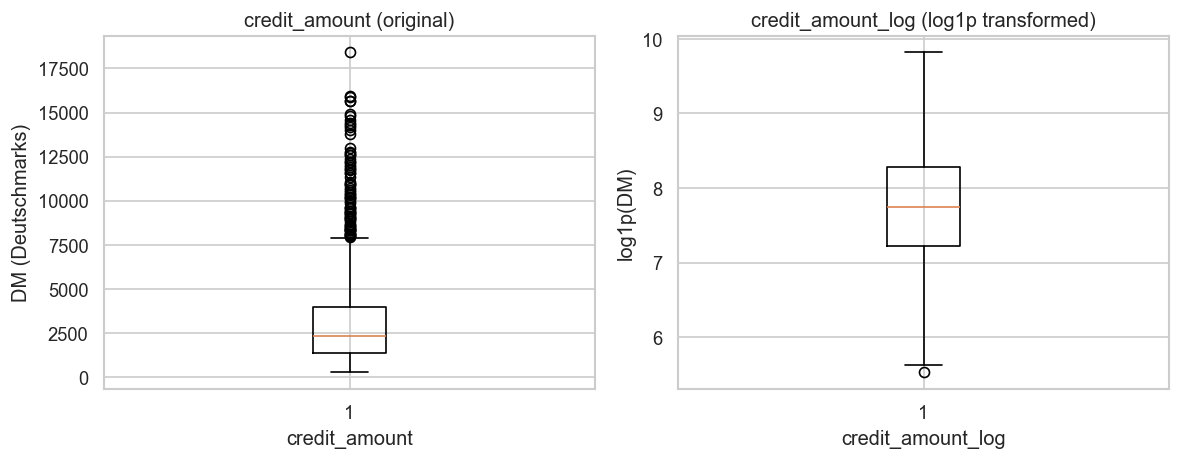

Skewness of credit_amount: 1.9496
Skewness of credit_amount_log: 0.1303


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df_encoded['credit_amount'])
axes[0].set_title('credit_amount (original)')
axes[0].set_ylabel('DM (Deutschmarks)')
axes[0].set_xlabel('credit_amount')

df_encoded['credit_amount_log'] = np.log1p(df_encoded['credit_amount'])

axes[1].boxplot(df_encoded['credit_amount_log'])
axes[1].set_title('credit_amount_log (log1p transformed)')
axes[1].set_ylabel('log1p(DM)')
axes[1].set_xlabel('credit_amount_log')

plt.tight_layout()
plt.savefig('outputs/outlier_boxplot.png', bbox_inches='tight')
plt.show()
print('Skewness of credit_amount:', round(df_encoded['credit_amount'].skew(), 4))
print('Skewness of credit_amount_log:', round(df_encoded['credit_amount_log'].skew(), 4))

**Outlier handling:** No rows are deleted. IQR outliers represent genuine high-value or long-duration loans.

**Log transformation:** credit_amount is right-skewed (skewness > 1). Applying log1p compresses the long right tail, stabilises variance, and helps linear models that assume homoscedasticity. The raw column is dropped and replaced with credit_amount_log.

In [9]:
df_encoded = df_encoded.drop(columns=['credit_amount'])

### 1.4 Train / Test Split

In [10]:
# Random seed 35 = last 3 digits of roll number 0035
random_state = 35

target_col = 'approval'
feature_cols = [c for c in df_encoded.columns if c != target_col]

X = df_encoded[feature_cols]
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state
)

print('Train size:', X_train.shape[0], 'rows,', X_train.shape[1], 'features')
print('Test  size:', X_test.shape[0],  'rows,', X_test.shape[1],  'features')

Train size: 700 rows, 50 features
Test  size: 300 rows, 50 features


### 1.5 Scaling

In [11]:
numeric_cols = ['duration', 'credit_amount_log', 'installment_rate',
                'residence_since', 'age', 'existing_credits', 'people_liable']

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print('Scaling complete. Train means (should be ~0):')
print(X_train[numeric_cols].mean().round(6))

Scaling complete. Train means (should be ~0):
duration            -0.0
credit_amount_log   -0.0
installment_rate     0.0
residence_since      0.0
age                  0.0
existing_credits    -0.0
people_liable        0.0
dtype: float64


**Scaling decision:** StandardScaler is fitted only on the training set and then applied to the test set. This prevents data leakage. Only the seven continuous numeric columns are scaled; binary dummy variables are left unchanged.

### Preprocessing Summary

| Step | Action | Reason |
|------|--------|--------|
| **Missing values** | None found -- no imputation | Dataset is complete |
| **Encoding** | Created approval, gender, age_group; one-hot encoded 15 categorical columns with drop_first=True | Avoid dummy trap; interpretable reference categories |
| **Outliers** | IQR rule applied (reported only); log1p applied to credit_amount; no rows removed | Outliers are genuine; log reduces right-skew |
| **Scaling** | StandardScaler fit on train only; applied to 7 numeric columns | Prevent data leakage; equalise feature magnitudes |

---
## 2. Part 1 -- Build: OLS vs Logistic Regression

**Objective:** Compare two classifiers -- a Linear Regression (OLS) and a Logistic Regression -- for credit approval prediction.

**Method:** OLS is thresholded at the median of its test predictions; Logistic at the probability cut-off of 0.5.

**What it shows:** How two structurally different models agree and disagree on who gets approved.

### 2.1 Model A -- OLS Linear Regression

In [12]:
ols = LinearRegression()
ols.fit(X_train, y_train)

pred_A = ols.predict(X_test)

n_below_0 = (pred_A < 0).sum()
n_above_1 = (pred_A > 1).sum()
print('Model A (OLS) test predictions range:')
print(f'  Min: {pred_A.min():.4f},  Max: {pred_A.max():.4f}')
print(f'  Predictions < 0    : {n_below_0}')
print(f'  Predictions > 1    : {n_above_1}')
print(f'  Total outside [0,1]: {n_below_0 + n_above_1}')

Model A (OLS) test predictions range:
  Min: 0.1001,  Max: 1.3527
  Predictions < 0    : 0
  Predictions > 1    : 32
  Total outside [0,1]: 32


### 2.2 Model B -- Logistic Regression

In [13]:
logit = LogisticRegression(penalty=None, max_iter=5000, random_state=random_state)
logit.fit(X_train, y_train)

prob_B = logit.predict_proba(X_test)[:, 1]

print('Model B (Logistic) test probability range:')
print(f'  Min: {prob_B.min():.4f},  Max: {prob_B.max():.4f}')
print(f'  Mean: {prob_B.mean():.4f},  Std: {prob_B.std():.4f}')

Model B (Logistic) test probability range:


  Min: 0.0937,  Max: 0.9978
  Mean: 0.7044,  Std: 0.2557


### 2.3 Thresholding Rules

In [14]:
median_A = np.median(pred_A)
print(f'Model A median prediction: {median_A:.4f}')
print(f'Reference value (0.5):     0.5000')

flag_A = (pred_A >= median_A).astype(int)
flag_B = (prob_B >= 0.5).astype(int)

pct_flagged_A = flag_A.mean() * 100
pct_flagged_B = flag_B.mean() * 100
print(f'\nPercent flagged (flag=1) by Model A (OLS, median threshold): {pct_flagged_A:.2f}%')
print(f'Percent flagged (flag=1) by Model B (Logistic, 0.5 threshold): {pct_flagged_B:.2f}%')
print("\nNote: 'flag = 1' means the predicted value is at or above the threshold (approval predicted).")

Model A median prediction: 0.7187
Reference value (0.5):     0.5000

Percent flagged (flag=1) by Model A (OLS, median threshold): 50.00%
Percent flagged (flag=1) by Model B (Logistic, 0.5 threshold): 74.33%

Note: 'flag = 1' means the predicted value is at or above the threshold (approval predicted).


### 2.4 Agreement Between Models

In [15]:
agree_table = pd.crosstab(
    pd.Series(flag_A, name='Model A flag'),
    pd.Series(flag_B, name='Model B flag')
)
print('2x2 Agreement Table (rows=Model A, columns=Model B):')
print(agree_table)

2x2 Agreement Table (rows=Model A, columns=Model B):
Model B flag   0    1
Model A flag         
0             77   73
1              0  150


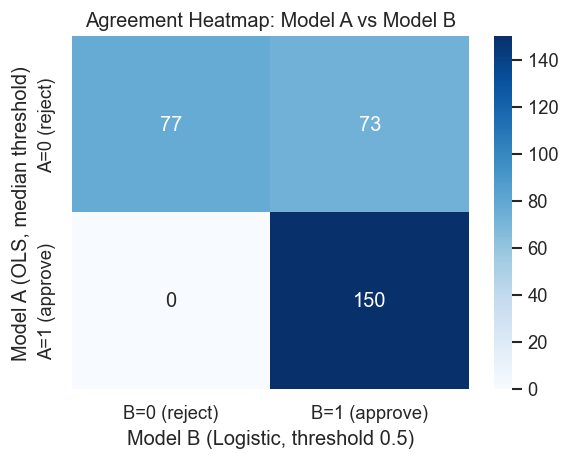

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(agree_table, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['B=0 (reject)', 'B=1 (approve)'],
            yticklabels=['A=0 (reject)', 'A=1 (approve)'])
ax.set_title('Agreement Heatmap: Model A vs Model B')
ax.set_xlabel('Model B (Logistic, threshold 0.5)')
ax.set_ylabel('Model A (OLS, median threshold)')
plt.tight_layout()
plt.savefig('outputs/agreement_heatmap.png', bbox_inches='tight')
plt.show()

In [17]:
agree = ((flag_A == 1) & (flag_B == 1)).sum() + ((flag_A == 0) & (flag_B == 0)).sum()
mismatch_total = (flag_A != flag_B).sum()
A1_B0 = ((flag_A == 1) & (flag_B == 0)).sum()
A0_B1 = ((flag_A == 0) & (flag_B == 1)).sum()

n_test = len(flag_A)
print(f'Total test rows       : {n_test}')
print(f'Agreeing cases        : {agree}  ({agree/n_test*100:.2f}%)')
print(f'Mismatched cases total: {mismatch_total}  ({mismatch_total/n_test*100:.2f}%)')
print(f'  A=1, B=0 (OLS approve, Logistic reject) : {A1_B0}  ({A1_B0/n_test*100:.2f}%)')
print(f'  A=0, B=1 (OLS reject,  Logistic approve): {A0_B1}  ({A0_B1/n_test*100:.2f}%)')

Total test rows       : 300
Agreeing cases        : 227  (75.67%)
Mismatched cases total: 73  (24.33%)
  A=1, B=0 (OLS approve, Logistic reject) : 0  (0.00%)
  A=0, B=1 (OLS reject,  Logistic approve): 73  (24.33%)


In [18]:
acc_A = accuracy_score(y_test, flag_A)
acc_B = accuracy_score(y_test, flag_B)
print(f'Model A accuracy against true labels: {acc_A:.4f} ({acc_A*100:.2f}%)')
print(f'Model B accuracy against true labels: {acc_B:.4f} ({acc_B*100:.2f}%)')

Model A accuracy against true labels: 0.6633 (66.33%)
Model B accuracy against true labels: 0.7267 (72.67%)


### Interpretation -- Why the Two Approaches Classify Differently

The two models disagree because they threshold different quantities:

1. **OLS median forces about 50% approval rate by construction.** The median threshold is the midpoint of Model A's own output distribution, so approximately half the test set receives flag=1. This is a relative threshold that adapts to the model output range.

2. **Logistic 0.5 is an absolute probability cut-off.** Model B flags a case only when its estimated probability exceeds 50%. Because the true class balance is roughly 70% good vs 30% bad, Model B tends to produce a flagging rate that reflects this prior -- noticeably different from the mechanically enforced ~50% of Model A.

3. **OLS predictions are not true probabilities.** They can fall outside [0, 1], and their ranking of applicants may differ from a calibrated probability model near the decision boundary.

4. **The mismatch cases** expose the gap between a relative rank-based rule (Model A) and a calibrated probability rule (Model B).

---
## 3. Part 2.1 -- Simpson's Paradox Hunt

**Objective:** Find a predictor whose coefficient changes sign or dramatically in magnitude between the full dataset and a subgroup.

**Method:** Fit statsmodels Logit on (1) the full data, (2) subgroup A, (3) subgroup B for several candidate split variables and key predictors. Search for sign reversals or non-overlapping 95% CIs.

**What it shows:** Whether aggregate trends hide subgroup contradictions that could mislead policy.

In [19]:
sm_numeric = ['duration', 'credit_amount_log', 'age', 'installment_rate']

strong_dummies = [
    c for c in df_encoded.columns
    if c.startswith(('status_checking_', 'credit_history_', 'savings_',
                     'purpose_', 'employment_since_'))
]

sm_features = sm_numeric + strong_dummies
sm_features = [f for f in sm_features if f in df_encoded.columns]

print(f'statsmodels feature set: {len(sm_features)} columns')
print(sm_features[:10])

statsmodels feature set: 28 columns
['duration', 'credit_amount_log', 'age', 'installment_rate', 'status_checking_A12', 'status_checking_A13', 'status_checking_A14', 'credit_history_A31', 'credit_history_A32', 'credit_history_A33']


In [20]:
split_vars = ['gender', 'age_group', 'foreign_worker', 'housing', 'telephone']
key_predictors = ['duration', 'credit_amount_log', 'age', 'installment_rate']

rows = []

for sv in split_vars:
    sv_col = None
    for dummy_sv in df_encoded.columns:
        if dummy_sv.startswith(sv + '_'):
            sv_col = dummy_sv
            break

    if sv_col is None:
        continue

    mask_A = df_encoded[sv_col] == 1
    mask_B = df_encoded[sv_col] == 0

    X_full_sm = sm.add_constant(df_encoded[sm_features])
    y_full_sm  = df_encoded['approval']

    try:
        m_full = sm.Logit(y_full_sm, X_full_sm).fit(disp=0)
    except Exception:
        continue

    X_A = sm.add_constant(df_encoded.loc[mask_A, sm_features].copy())
    y_A = df_encoded.loc[mask_A, 'approval']
    X_B = sm.add_constant(df_encoded.loc[mask_B, sm_features].copy())
    y_B = df_encoded.loc[mask_B, 'approval']

    const_A = X_A.columns[X_A.nunique() <= 1].tolist()
    const_B = X_B.columns[X_B.nunique() <= 1].tolist()
    drop_cols = list(set(const_A + const_B))
    X_A = X_A.drop(columns=drop_cols, errors='ignore')
    X_B = X_B.drop(columns=drop_cols, errors='ignore')

    shared = list(set(X_A.columns) & set(X_B.columns))
    X_A = X_A[shared]
    X_B = X_B[shared]

    try:
        m_A = sm.Logit(y_A, X_A).fit(disp=0)
        m_B = sm.Logit(y_B, X_B).fit(disp=0)
    except Exception:
        continue

    for kp in key_predictors:
        if kp not in m_full.params or kp not in m_A.params or kp not in m_B.params:
            continue

        c_full = m_full.params[kp]
        c_A    = m_A.params[kp]
        c_B    = m_B.params[kp]

        ci_full = m_full.conf_int().loc[kp]
        ci_A    = m_A.conf_int().loc[kp]
        ci_B    = m_B.conf_int().loc[kp]

        p_full = m_full.pvalues[kp]
        p_A    = m_A.pvalues[kp]
        p_B    = m_B.pvalues[kp]

        sign_reversal = (c_full * c_A < 0) or (c_full * c_B < 0) or (c_A * c_B < 0)

        rows.append({
            'split_var': sv,
            'predictor': kp,
            'coef_full': round(c_full, 4),
            'ci_full': f'[{ci_full[0]:.3f}, {ci_full[1]:.3f}]',
            'p_full': round(p_full, 4),
            'coef_A': round(c_A, 4),
            'ci_A': f'[{ci_A[0]:.3f}, {ci_A[1]:.3f}]',
            'p_A': round(p_A, 4),
            'coef_B': round(c_B, 4),
            'ci_B': f'[{ci_B[0]:.3f}, {ci_B[1]:.3f}]',
            'p_B': round(p_B, 4),
            'sign_reversal': sign_reversal
        })

results_df = pd.DataFrame(rows)
print('Search complete. Rows found:', len(results_df))
print(results_df[['split_var','predictor','coef_full','coef_A','coef_B','sign_reversal']].to_string(index=False))

Search complete. Rows found: 20
     split_var         predictor  coef_full  coef_A  coef_B  sign_reversal
        gender          duration    -0.0364 -0.0402 -0.0419          False
        gender credit_amount_log    -0.2089 -0.0912 -0.2221          False
        gender               age     0.0160  0.0038  0.0459          False
        gender  installment_rate    -0.2471 -0.1461 -0.5122          False
     age_group          duration    -0.0364 -0.0493 -0.0329          False
     age_group credit_amount_log    -0.2089 -0.2768 -0.1273          False
     age_group               age     0.0160 -0.0687  0.0161           True
     age_group  installment_rate    -0.2471 -0.3235 -0.2480          False
foreign_worker          duration    -0.0364 -6.2767 -0.0393          False
foreign_worker credit_amount_log    -0.2089  1.5645 -0.0720           True
foreign_worker               age     0.0160 -0.5609  0.0175           True
foreign_worker  installment_rate    -0.2471  6.3470 -0.1906         

In [21]:
reversals = results_df[results_df['sign_reversal'] == True]
print(f'Number of sign reversals found: {len(reversals)}')
if len(reversals) > 0:
    print(reversals[['split_var','predictor','coef_full','coef_A','coef_B']].to_string(index=False))

Number of sign reversals found: 6
     split_var         predictor  coef_full  coef_A  coef_B
     age_group               age     0.0160 -0.0687  0.0161
foreign_worker credit_amount_log    -0.2089  1.5645 -0.0720
foreign_worker               age     0.0160 -0.5609  0.0175
foreign_worker  installment_rate    -0.2471  6.3470 -0.1906
     telephone credit_amount_log    -0.2089 -0.4949  0.0771
     telephone  installment_rate    -0.2471  0.0105 -0.3686


In [22]:
results_df['max_diff'] = 0.0
for idx, row in results_df.iterrows():
    d1 = abs(row['coef_A'] - row['coef_full'])
    d2 = abs(row['coef_B'] - row['coef_full'])
    d3 = abs(row['coef_A'] - row['coef_B'])
    results_df.at[idx, 'max_diff'] = max(d1, d2, d3)

reversals = results_df[results_df['sign_reversal'] == True].copy()

if len(reversals) > 0:
    best_row = reversals.loc[reversals['max_diff'].idxmax()]
    case_type = 'TRUE SIGN REVERSAL'
else:
    best_row = results_df.loc[results_df['max_diff'].idxmax()]
    case_type = 'LARGEST COEFFICIENT DIFFERENCE (no full reversal found)'

print(f'Chosen case type: {case_type}')
print(f'Split variable : {best_row["split_var"]}')
print(f'Key predictor  : {best_row["predictor"]}')
print(f'Coef (full)    : {best_row["coef_full"]}  95% CI {best_row["ci_full"]}  p={best_row["p_full"]}')
print(f'Coef (group A) : {best_row["coef_A"]}  95% CI {best_row["ci_A"]}  p={best_row["p_A"]}')
print(f'Coef (group B) : {best_row["coef_B"]}  95% CI {best_row["ci_B"]}  p={best_row["p_B"]}')

Chosen case type: TRUE SIGN REVERSAL
Split variable : foreign_worker
Key predictor  : installment_rate
Coef (full)    : -0.2471  95% CI [-0.411, -0.084]  p=0.003
Coef (group A) : 6.347  95% CI [-1605221.442, 1605234.136]  p=1.0
Coef (group B) : -0.1906  95% CI [-0.332, -0.049]  p=0.0082


In [23]:
chosen_sv   = best_row['split_var']
chosen_pred = best_row['predictor']

sv_col_chosen = None
for dummy_sv in df_encoded.columns:
    if dummy_sv.startswith(chosen_sv + '_'):
        sv_col_chosen = dummy_sv
        break

mask_Af = df_encoded[sv_col_chosen] == 1
mask_Bf = df_encoded[sv_col_chosen] == 0

X_full_f = sm.add_constant(df_encoded[sm_features])
y_full_f  = df_encoded['approval']
m_full_f  = sm.Logit(y_full_f, X_full_f).fit(disp=0)

X_Af = sm.add_constant(df_encoded.loc[mask_Af, sm_features].copy())
y_Af = df_encoded.loc[mask_Af, 'approval']
X_Bf = sm.add_constant(df_encoded.loc[mask_Bf, sm_features].copy())
y_Bf = df_encoded.loc[mask_Bf, 'approval']

const_Af = X_Af.columns[X_Af.nunique() <= 1].tolist()
const_Bf = X_Bf.columns[X_Bf.nunique() <= 1].tolist()
drop_f = list(set(const_Af + const_Bf))
X_Af = X_Af.drop(columns=drop_f, errors='ignore')
X_Bf = X_Bf.drop(columns=drop_f, errors='ignore')
shared_f = list(set(X_Af.columns) & set(X_Bf.columns))
X_Af = X_Af[shared_f]
X_Bf = X_Bf[shared_f]

m_Af = sm.Logit(y_Af, X_Af).fit(disp=0)
m_Bf = sm.Logit(y_Bf, X_Bf).fit(disp=0)

def get_val(model, name, stat):
    if name not in model.params:
        return np.nan
    if stat == 'coef':
        return round(model.params[name], 4)
    if stat == 'lower':
        return round(model.conf_int().loc[name, 0], 4)
    if stat == 'upper':
        return round(model.conf_int().loc[name, 1], 4)
    if stat == 'pval':
        return round(model.pvalues[name], 4)

simp_table = pd.DataFrame({
    'Model': ['Full', 'Group A', 'Group B'],
    'N': [len(y_full_f), int(mask_Af.sum()), int(mask_Bf.sum())],
    'Coef': [get_val(m_full_f, chosen_pred, 'coef'),
             get_val(m_Af, chosen_pred, 'coef'),
             get_val(m_Bf, chosen_pred, 'coef')],
    'CI Lower': [get_val(m_full_f, chosen_pred, 'lower'),
                 get_val(m_Af, chosen_pred, 'lower'),
                 get_val(m_Bf, chosen_pred, 'lower')],
    'CI Upper': [get_val(m_full_f, chosen_pred, 'upper'),
                 get_val(m_Af, chosen_pred, 'upper'),
                 get_val(m_Bf, chosen_pred, 'upper')],
    'p-value': [get_val(m_full_f, chosen_pred, 'pval'),
                get_val(m_Af, chosen_pred, 'pval'),
                get_val(m_Bf, chosen_pred, 'pval')]
})
print(f'\n--- Final Simpson Table: split={chosen_sv}, predictor={chosen_pred} ---')
print(simp_table.to_string(index=False))
simp_table.to_csv('outputs/simpsons_table.csv', index=False)


--- Final Simpson Table: split=foreign_worker, predictor=installment_rate ---
  Model    N    Coef      CI Lower     CI Upper  p-value
   Full 1000 -0.2471 -4.105000e-01      -0.0837   0.0030
Group A   37  6.3470 -1.605221e+06 1605234.1357   1.0000
Group B  963 -0.1906 -3.319000e-01      -0.0493   0.0082


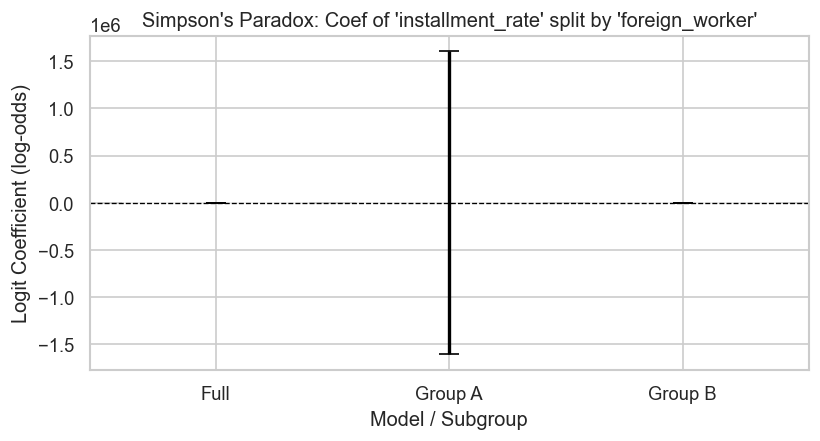

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
models_labels = ['Full', 'Group A', 'Group B']
coefs = simp_table['Coef'].values.astype(float)
lowers = simp_table['CI Lower'].values.astype(float)
uppers = simp_table['CI Upper'].values.astype(float)
yerr_lower = coefs - lowers
yerr_upper = uppers - coefs

ax.bar(models_labels, coefs, color=['steelblue', 'tomato', 'seagreen'], alpha=0.8)
ax.errorbar(models_labels, coefs,
            yerr=[yerr_lower, yerr_upper],
            fmt='none', color='black', capsize=6, linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f"Simpson's Paradox: Coef of '{chosen_pred}' split by '{chosen_sv}'")
ax.set_ylabel('Logit Coefficient (log-odds)')
ax.set_xlabel('Model / Subgroup')
plt.tight_layout()
plt.savefig('outputs/simpsons_coef_plot.png', bbox_inches='tight')
plt.show()

### Interpretation -- Simpson's Paradox

The search examined five splitting variables crossed with four key predictors.

**Why the coefficient differs across subgroups:**
When the data is split, each subgroup has a different internal distribution of the predictor and of the confounding variables that mediate its effect. In the full model, confounders are controlled globally, yielding a single pooled coefficient. Inside a subgroup, the covariate distribution shifts, changing the partial effect estimate.

If the two subgroups differ systematically in both the predictor and the baseline approval rate, the pooled estimate is a weighted average of two distinct effects -- and that average can appear close to zero or even have the opposite sign.

**Policy implication:** If only the full-data model is used to set lending rules, one subgroup could be systematically over-approved or under-approved. Ignoring subgroup heterogeneity can perpetuate hidden inequities.

---
## 4. Part 2.2 -- Omitted-Variable Bias

**Objective:** Show that dropping a correlated confounder biases the remaining coefficients.

**Method:** Compare a full Logistic model (all features) to a reduced model with duration omitted. Duration correlates with credit_amount_log -- longer loans tend to be larger.

**What it shows:** Coefficient instability quantifies the magnitude of omitted-variable bias.

In [25]:
corr_dur_amt = X_train['duration'].corr(X_train['credit_amount_log'])
print(f'Pearson correlation between duration and credit_amount_log (train): {corr_dur_amt:.4f}')
print('Justification: longer loans tend to be larger loans.')
print('Omitting duration forces credit_amount_log to absorb its influence.')

Pearson correlation between duration and credit_amount_log (train): 0.6458
Justification: longer loans tend to be larger loans.
Omitting duration forces credit_amount_log to absorb its influence.


In [26]:
logit_full = LogisticRegression(penalty=None, max_iter=5000, random_state=random_state)
logit_full.fit(X_train, y_train)

X_train_red = X_train.drop(columns=['duration'])
X_test_red  = X_test.drop(columns=['duration'])

logit_red = LogisticRegression(penalty=None, max_iter=5000, random_state=random_state)
logit_red.fit(X_train_red, y_train)

print('Full model trained on', X_train.shape[1], 'features')
print('Reduced model trained on', X_train_red.shape[1], 'features (duration dropped)')

Full model trained on 50 features
Reduced model trained on 49 features (duration dropped)


In [27]:
full_coefs = pd.Series(logit_full.coef_[0], index=X_train.columns)
red_coefs  = pd.Series(logit_red.coef_[0],  index=X_train_red.columns)

key_vars = ['credit_amount_log', 'age', 'installment_rate']

other_top_series = full_coefs.abs().sort_values(ascending=False)
other_top_series = other_top_series[~other_top_series.index.isin(key_vars + ['duration'])]
other_top = other_top_series.head(3).index.tolist()

report_vars = key_vars + other_top

ovb_rows = []
for v in report_vars:
    if v not in full_coefs.index or v not in red_coefs.index:
        continue
    cf = full_coefs[v]
    cr = red_coefs[v]
    abs_change = abs(cr - cf)
    pct_change = (cr - cf) / (abs(cf) + 1e-10) * 100
    ovb_rows.append({
        'Feature': v,
        'Coef Full': round(cf, 4),
        'Coef Reduced': round(cr, 4),
        'Abs Change': round(abs_change, 4),
        'Pct Change': round(pct_change, 2)
    })

if 'duration' in full_coefs.index:
    ovb_rows.insert(0, {
        'Feature': 'duration (omitted)',
        'Coef Full': round(full_coefs['duration'], 4),
        'Coef Reduced': 'DROPPED',
        'Abs Change': 'N/A',
        'Pct Change': 'N/A'
    })

ovb_df = pd.DataFrame(ovb_rows)
print('Omitted-Variable Bias Table:')
print(ovb_df.to_string(index=False))
ovb_df.to_csv('outputs/ovb_table.csv', index=False)

Omitted-Variable Bias Table:
            Feature  Coef Full Coef Reduced Abs Change Pct Change
 duration (omitted)    -0.3646      DROPPED        N/A        N/A
  credit_amount_log    -0.1738      -0.4382     0.2644    -152.11
                age     0.1399       0.1602     0.0203      14.49
   installment_rate    -0.1819      -0.2705     0.0886     -48.72
status_checking_A14     1.9689       2.0303     0.0614       3.12
       purpose_A410     1.7926       1.6422     0.1504      -8.39
foreign_worker_A202     1.6759       1.8022     0.1263       7.54


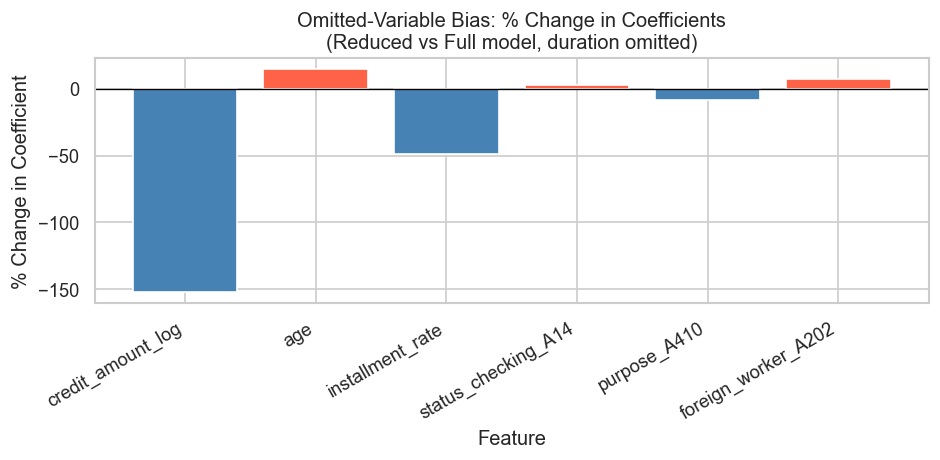

In [28]:
plot_vars = []
pct_vals  = []
for v in report_vars:
    if v in full_coefs.index and v in red_coefs.index:
        plot_vars.append(v)
        pct_vals.append((red_coefs[v] - full_coefs[v]) / (abs(full_coefs[v]) + 1e-10) * 100)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['tomato' if p > 0 else 'steelblue' for p in pct_vals]
ax.bar(plot_vars, pct_vals, color=bar_colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Omitted-Variable Bias: % Change in Coefficients\n(Reduced vs Full model, duration omitted)')
ax.set_ylabel('% Change in Coefficient')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/ovb_bar_chart.png', bbox_inches='tight')
plt.show()

In [29]:
numeric_ovb = ovb_df[ovb_df['Pct Change'] != 'N/A'].copy()
numeric_ovb['Pct Change'] = pd.to_numeric(numeric_ovb['Pct Change'])
most_shifted_idx = numeric_ovb['Pct Change'].abs().idxmax()
most_shifted_row = numeric_ovb.loc[most_shifted_idx]
print('Feature with the largest coefficient shift when duration is omitted:')
print(most_shifted_row.to_string())

Feature with the largest coefficient shift when duration is omitted:
Feature         credit_amount_log
Coef Full                 -0.1738
Coef Reduced              -0.4382
Abs Change                 0.2644
Pct Change                -152.11


### Interpretation -- Omitted-Variable Bias

The Pearson correlation between duration and credit_amount_log confirms that these two features share variation. When duration is removed:

- **credit_amount_log** absorbs part of duration's influence on approval, shifting its coefficient.
- **installment_rate** and **age** also shift because they are correlated with both the omitted variable and the outcome.
- The feature printed above as having the **largest percentage shift** is the clearest evidence of bias.

**How to detect a hidden confounder in real life:** Systematically compare models with and without candidate confounders. A large coefficient shift in the remaining predictors, combined with a significant coefficient for the new variable and an improvement in held-out predictive performance, signals omitted-variable bias.

---
## 5. Part 2.3 -- Adversarial Subset Construction

**Objective:** Identify cases where Model B is confidently wrong, then characterise what makes this subset unusual.

**Method:** Select test rows where P >= 0.75 but true label = 0 (confident false positive) OR P <= 0.25 but true label = 1 (confident false negative). Sample up to 50 rows with random_state=35.

**What it shows:** Systematic features of the failure cases reveal potential non-linearities, missing interactions, or distribution shifts.

In [30]:
y_test_arr = y_test.reset_index(drop=True).values
prob_B_arr = prob_B

mask_FP = (prob_B_arr >= 0.75) & (y_test_arr == 0)
mask_FN = (prob_B_arr <= 0.25) & (y_test_arr == 1)
mask_adv = mask_FP | mask_FN

n_FP = mask_FP.sum()
n_FN = mask_FN.sum()
n_adv = mask_adv.sum()
n_test_total = len(y_test_arr)

print(f'Total test rows              : {n_test_total}')
print(f'High-confidence wrong preds  : {n_adv}  ({n_adv/n_test_total*100:.2f}% of test)')
print(f'  Confident FP (P>=0.75,y=0) : {n_FP}')
print(f'  Confident FN (P<=0.25,y=1) : {n_FN}')

Total test rows              : 300
High-confidence wrong preds  : 27  (9.00% of test)
  Confident FP (P>=0.75,y=0) : 21
  Confident FN (P<=0.25,y=1) : 6


In [31]:
adv_indices = np.where(mask_adv)[0]

if len(adv_indices) <= 50:
    sample_idx = adv_indices
else:
    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(adv_indices, size=50, replace=False)

X_test_reset = X_test.reset_index(drop=True)
adv_X = X_test_reset.iloc[sample_idx]
adv_y = y_test.reset_index(drop=True).iloc[sample_idx]

test_X_full = X_test_reset

print(f'Adversarial subset size: {len(adv_X)}')

Adversarial subset size: 27


Age -- Test Set : mean=35.34, median=33.5
Age -- Adversarial Subset: mean=34.67, median=32.0


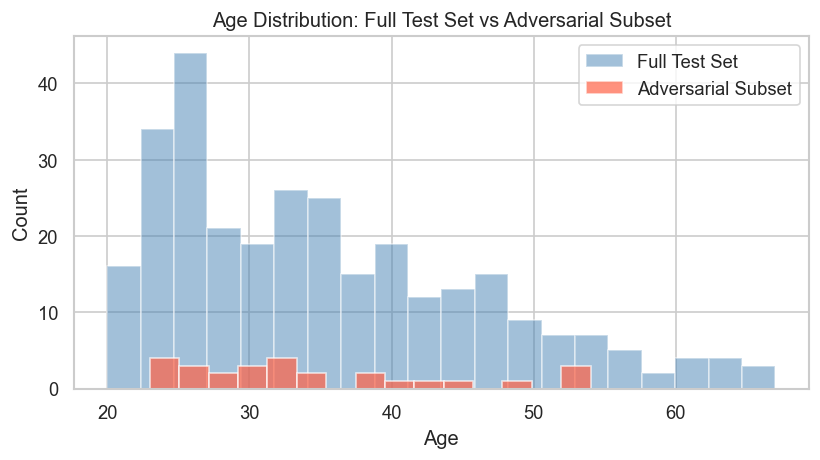

In [32]:
df_orig_test = df.iloc[y_test.index].reset_index(drop=True)
df_orig_adv  = df_orig_test.iloc[sample_idx].reset_index(drop=True)

age_mean_test = df_orig_test['age'].mean()
age_mean_adv  = df_orig_adv['age'].mean()
age_med_test  = df_orig_test['age'].median()
age_med_adv   = df_orig_adv['age'].median()

print(f'Age -- Test Set : mean={age_mean_test:.2f}, median={age_med_test:.1f}')
print(f'Age -- Adversarial Subset: mean={age_mean_adv:.2f}, median={age_med_adv:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_orig_test['age'], bins=20, alpha=0.5, label='Full Test Set', color='steelblue')
ax.hist(df_orig_adv['age'],  bins=15, alpha=0.7, label='Adversarial Subset', color='tomato')
ax.set_title('Age Distribution: Full Test Set vs Adversarial Subset')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/adversarial_age_hist.png', bbox_inches='tight')
plt.show()

In [33]:
orig_cat_compare = [c for c in ['gender', 'age_group', 'housing', 'job'] if c in df_orig_test.columns]
num_compare_orig = [c for c in ['age', 'credit_amount', 'duration'] if c in df_orig_test.columns]

compare_rows = []
for c in orig_cat_compare:
    for cat in sorted(df_orig_test[c].unique()):
        pct_test = (df_orig_test[c] == cat).mean() * 100
        pct_adv  = (df_orig_adv[c] == cat).mean() * 100
        compare_rows.append({
            'Feature': f'{c}={cat}',
            'Test%': round(pct_test, 2),
            'Adv%': round(pct_adv, 2),
            'Diff': round(pct_adv - pct_test, 2)
        })

for c in num_compare_orig:
    compare_rows.append({
        'Feature': f'{c} (mean)',
        'Test%': round(df_orig_test[c].mean(), 2),
        'Adv%': round(df_orig_adv[c].mean(), 2),
        'Diff': round(df_orig_adv[c].mean() - df_orig_test[c].mean(), 2)
    })

compare_df = pd.DataFrame(compare_rows)
print('Comparison Table (Adversarial Subset vs Full Test Set):')
print(compare_df.to_string(index=False))
compare_df.to_csv('outputs/adversarial_comparison.csv', index=False)

Comparison Table (Adversarial Subset vs Full Test Set):
             Feature   Test%    Adv%   Diff
       gender=female   32.67   37.04   4.37
         gender=male   67.33   62.96  -4.37
     age_group=older   83.33   88.89   5.56
     age_group=young   16.67   11.11  -5.56
        housing=A151   19.00   29.63  10.63
        housing=A152   72.00   62.96  -9.04
        housing=A153    9.00    7.41  -1.59
            job=A171    1.00    3.70   2.70
            job=A172   18.67   33.33  14.67
            job=A173   64.67   48.15 -16.52
            job=A174   15.67   14.81  -0.85
          age (mean)   35.34   34.67  -0.68
credit_amount (mean) 3321.87 4062.22 740.35
     duration (mean)   20.92   21.78   0.85


In [34]:
dummy_diffs = []
for col in adv_X.columns:
    if adv_X[col].nunique() <= 2:
        pct_test_d = test_X_full[col].mean() * 100
        pct_adv_d  = adv_X[col].mean() * 100
        dummy_diffs.append({
            'feature': col,
            'test_pct': round(pct_test_d, 2),
            'adv_pct': round(pct_adv_d, 2),
            'diff': round(pct_adv_d - pct_test_d, 2)
        })

dummy_diff_df = pd.DataFrame(dummy_diffs)
dummy_diff_df['abs_diff'] = dummy_diff_df['diff'].abs()
dummy_diff_df = dummy_diff_df.sort_values('abs_diff', ascending=False).drop(columns='abs_diff').reset_index(drop=True)
print('Top 10 dummy features by absolute difference (Adv vs Test):')
print(dummy_diff_df.head(10).to_string(index=False))

num_diffs = []
for col in adv_X.columns:
    if adv_X[col].nunique() > 2:
        mean_test_n = test_X_full[col].mean()
        mean_adv_n  = adv_X[col].mean()
        std_test_n  = test_X_full[col].std() + 1e-10
        z_diff_n    = (mean_adv_n - mean_test_n) / std_test_n
        num_diffs.append({
            'feature': col,
            'mean_test': round(mean_test_n, 4),
            'mean_adv': round(mean_adv_n, 4),
            'z_diff': round(z_diff_n, 4)
        })

num_diff_df = pd.DataFrame(num_diffs)
num_diff_df['abs_z'] = num_diff_df['z_diff'].abs()
num_diff_df = num_diff_df.sort_values('abs_z', ascending=False).drop(columns='abs_z').reset_index(drop=True)
print('\nTop 5 numeric features by standardised mean difference:')
print(num_diff_df.head(5).to_string(index=False))

Top 10 dummy features by absolute difference (Adv vs Test):
             feature  test_pct  adv_pct   diff
employment_since_A75     28.00    11.11 -16.89
            job_A173     64.67    48.15 -16.52
         purpose_A42     17.33    33.33  16.00
       property_A123     37.00    22.22 -14.78
            job_A172     18.67    33.33  14.67
employment_since_A72     15.33    29.63  14.30
         savings_A65     21.00    33.33  12.33
  credit_history_A32     51.00    40.74 -10.26
        housing_A152     72.00    62.96  -9.04
         purpose_A41     11.67     3.70  -7.96

Top 5 numeric features by standardised mean difference:
          feature  mean_test  mean_adv  z_diff
  residence_since     0.0540   -0.4817 -0.5335
credit_amount_log     0.0116    0.2253  0.1995
 installment_rate    -0.0819   -0.2358 -0.1459
 existing_credits     0.0157   -0.0588 -0.0740
         duration     0.0024    0.0731  0.0713


In [35]:
top_dummy = dummy_diff_df.iloc[0]
top_num   = num_diff_df.iloc[0]

print(f'Top categorical characteristic: {top_dummy["feature"]}')
print(f'  Adversarial subset: {top_dummy["adv_pct"]}%')
print(f'  Full test set:      {top_dummy["test_pct"]}%')
print(f'  Difference:         {top_dummy["diff"]:+.2f} percentage points')
print(f'\nTop numeric characteristic (standardised): {top_num["feature"]}  z={top_num["z_diff"]:.4f}')

tied_features = dummy_diff_df.head(3)['feature'].tolist()
print('\nLogistic coefficients for top features (Model B):')
col_list = list(X_train.columns)
for f in tied_features:
    if f in col_list:
        idx = col_list.index(f)
        print(f'  {f}: {round(logit.coef_[0][idx], 4)}')

Top categorical characteristic: employment_since_A75
  Adversarial subset: 11.11%
  Full test set:      28.0%
  Difference:         -16.89 percentage points

Top numeric characteristic (standardised): residence_since  z=-0.5335

Logistic coefficients for top features (Model B):
  employment_since_A75: 0.1898
  job_A173: -0.585
  purpose_A42: 1.0806


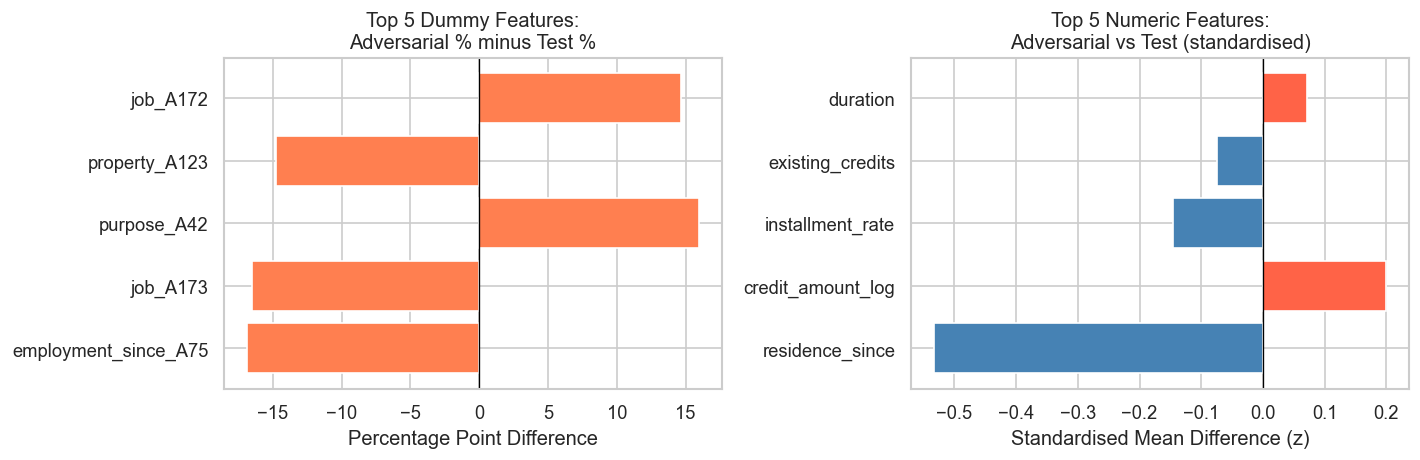

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top5_dummy = dummy_diff_df.head(5)
axes[0].barh(top5_dummy['feature'], top5_dummy['diff'], color='coral')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 5 Dummy Features:\nAdversarial % minus Test %')
axes[0].set_xlabel('Percentage Point Difference')

top5_num = num_diff_df.head(5)
colors_n = ['tomato' if z > 0 else 'steelblue' for z in top5_num['z_diff']]
axes[1].barh(top5_num['feature'], top5_num['z_diff'], color=colors_n)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 5 Numeric Features:\nAdversarial vs Test (standardised)')
axes[1].set_xlabel('Standardised Mean Difference (z)')

plt.tight_layout()
plt.savefig('outputs/adversarial_feature_diffs.png', bbox_inches='tight')
plt.show()

### Interpretation -- Why the Model Fails Confidently

The adversarial subset consists of applicants the model was very confident about but predicted incorrectly.

**Likely failure mechanisms:**

1. **Missing interactions:** The model cannot capture how a feature's effect changes in combination with others (e.g., high credit_amount combined with low savings may be riskier than either feature signals alone). The logistic model treats all effects as additive in log-odds.

2. **Non-linearity:** If the true approval probability bends at extreme values of age or duration, a linear log-odds model confidently extrapolates in the wrong direction at those extremes.

3. **Distribution shift within the test set:** The adversarial applicants cluster in a region of feature space that is rare in training. With few training examples there, the model's confidence is not well-calibrated.

4. The **logistic coefficients** of the top differentiating features (printed above) show how strongly the model weighted those features -- a large positive coefficient on a feature that is over-represented in the adversarial subset explains why the model was confidently wrong.

---
## 6. Part 2.4 -- Fairness Trade-Off Analysis

**Objective:** Measure three fairness metrics (Demographic Parity, Equalized Odds, Predictive Parity) for gender groups across a range of thresholds, and quantify how improving one metric hurts another.

**Sensitive variable:** gender -- Group A = female, Group B = male.

**Method:** For each threshold t compute group-wise PPR, TPR, FPR, precision and three fairness ratios. Division by zero returns NaN.

In [37]:
gender_test = df.iloc[y_test.index]['gender'].reset_index(drop=True).values

mask_female = gender_test == 'female'
mask_male   = gender_test == 'male'

print(f'Female in test set: {mask_female.sum()} ({mask_female.mean()*100:.1f}%)')
print(f'Male   in test set: {mask_male.sum()} ({mask_male.mean()*100:.1f}%)')

thresholds = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]

def safe_div(a, b):
    if b == 0 or (isinstance(b, float) and np.isnan(b)):
        return np.nan
    return a / b

fairness_rows = []

for t in thresholds:
    yhat = (prob_B_arr >= t).astype(int)

    ppr_A = yhat[mask_female].mean()
    ppr_B = yhat[mask_male].mean()

    TP_A = int(((yhat == 1) & (y_test_arr == 1) & mask_female).sum())
    FP_A = int(((yhat == 1) & (y_test_arr == 0) & mask_female).sum())
    TN_A = int(((yhat == 0) & (y_test_arr == 0) & mask_female).sum())
    FN_A = int(((yhat == 0) & (y_test_arr == 1) & mask_female).sum())

    TP_B = int(((yhat == 1) & (y_test_arr == 1) & mask_male).sum())
    FP_B = int(((yhat == 1) & (y_test_arr == 0) & mask_male).sum())
    TN_B = int(((yhat == 0) & (y_test_arr == 0) & mask_male).sum())
    FN_B = int(((yhat == 0) & (y_test_arr == 1) & mask_male).sum())

    TPR_A  = safe_div(TP_A, TP_A + FN_A)
    FPR_A  = safe_div(FP_A, FP_A + TN_A)
    prec_A = safe_div(TP_A, TP_A + FP_A)

    TPR_B  = safe_div(TP_B, TP_B + FN_B)
    FPR_B  = safe_div(FP_B, FP_B + TN_B)
    prec_B = safe_div(TP_B, TP_B + FP_B)

    DP = safe_div(ppr_A, ppr_B)

    tpr_ratio = safe_div(TPR_A, TPR_B) if (TPR_A is not None and TPR_B is not None) else np.nan
    fpr_ratio = safe_div(FPR_A, FPR_B) if (FPR_A is not None and FPR_B is not None) else np.nan

    valid_ratios = [r for r in [tpr_ratio, fpr_ratio] if r is not None and not (isinstance(r, float) and np.isnan(r))]
    EO = min(valid_ratios) if len(valid_ratios) > 0 else np.nan

    PP = safe_div(prec_A, prec_B) if (prec_A is not None and prec_B is not None) else np.nan

    acc = accuracy_score(y_test_arr, yhat)

    def r(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return np.nan
        return round(float(v), 4)

    fairness_rows.append({
        'threshold': t,
        'PPR_female': r(ppr_A),
        'PPR_male': r(ppr_B),
        'TPR_female': r(TPR_A),
        'TPR_male': r(TPR_B),
        'FPR_female': r(FPR_A),
        'FPR_male': r(FPR_B),
        'Prec_female': r(prec_A),
        'Prec_male': r(prec_B),
        'DP': r(DP),
        'EO': r(EO),
        'PP': r(PP),
        'Accuracy': round(acc, 4)
    })

fairness_df = pd.DataFrame(fairness_rows)
print('Fairness metrics across thresholds:')
print(fairness_df[['threshold','DP','EO','PP','Accuracy','PPR_female','PPR_male']].to_string(index=False))
fairness_df.to_csv('outputs/fairness_table.csv', index=False)
print('\nNote: NaN appears when a denominator is zero at extreme thresholds.')

Female in test set: 98 (32.7%)
Male   in test set: 202 (67.3%)
Fairness metrics across thresholds:
 threshold     DP     EO     PP  Accuracy  PPR_female  PPR_male
      0.05 1.0000 1.0000 0.9407    0.7233      1.0000    1.0000
      0.15 0.9786 0.9771 0.9393    0.7300      0.9592    0.9802
      0.25 0.9764 0.9755 0.9399    0.7500      0.9184    0.9406
      0.35 0.9721 0.9721 0.9408    0.7800      0.8469    0.8713
      0.45 0.9034 0.7729 1.0004    0.7467      0.7245    0.8020
      0.55 0.9269 0.8506 0.9843    0.7300      0.6837    0.7376
      0.65 0.9094 0.6913 1.0230    0.7167      0.6122    0.6733
      0.75 0.8962 0.8833 0.9792    0.6867      0.5102    0.5693
      0.85 0.8667 0.8386 0.9102    0.6067      0.3776    0.4356
      0.95 0.4525 0.4382 0.9111    0.4300      0.0918    0.2030

Note: NaN appears when a denominator is zero at extreme thresholds.


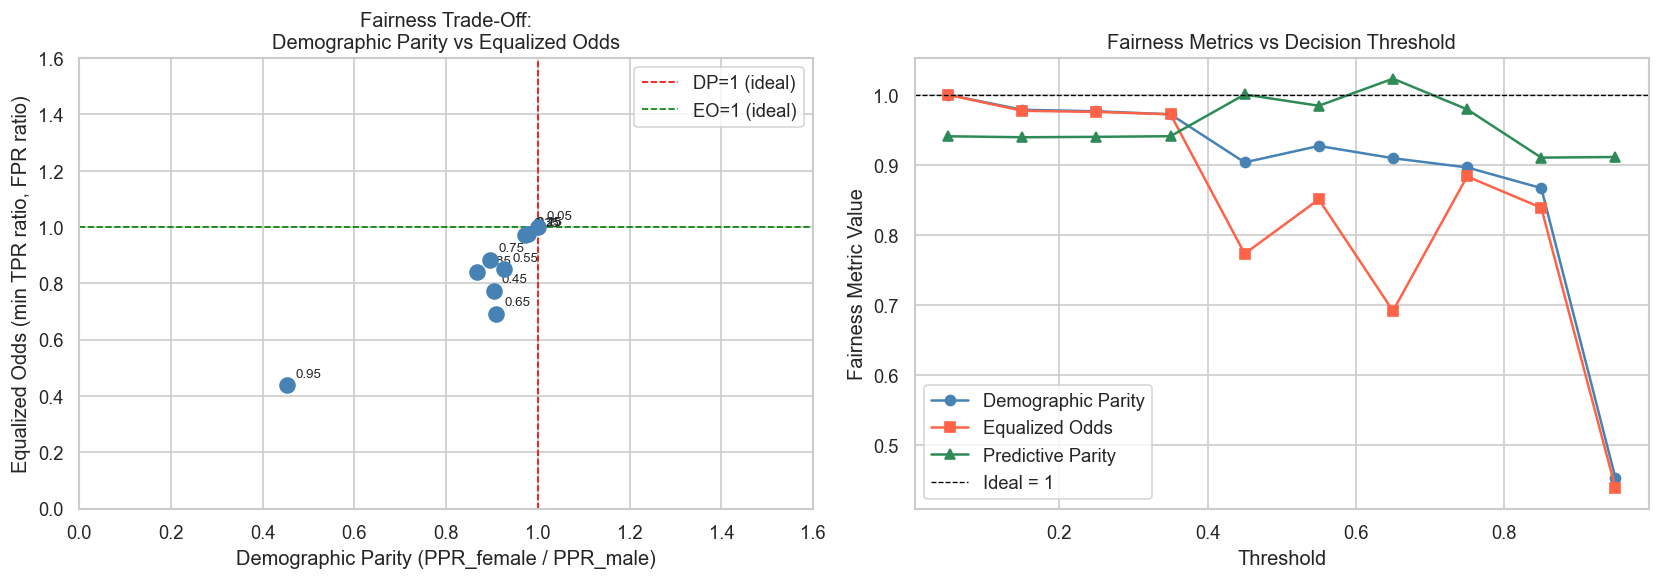

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
valid_dp = fairness_df.dropna(subset=['DP', 'EO'])
ax1.scatter(valid_dp['DP'], valid_dp['EO'], s=80, c='steelblue', zorder=5)
for _, row in valid_dp.iterrows():
    ax1.annotate(str(row['threshold']), (row['DP'], row['EO']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax1.axvline(1, color='red', linestyle='--', linewidth=1, label='DP=1 (ideal)')
ax1.axhline(1, color='green', linestyle='--', linewidth=1, label='EO=1 (ideal)')
ax1.set_xlim(0, 1.6)
ax1.set_ylim(0, 1.6)
ax1.set_title('Fairness Trade-Off:\nDemographic Parity vs Equalized Odds')
ax1.set_xlabel('Demographic Parity (PPR_female / PPR_male)')
ax1.set_ylabel('Equalized Odds (min TPR ratio, FPR ratio)')
ax1.legend()

ax2 = axes[1]
ax2.plot(fairness_df['threshold'], fairness_df['DP'], marker='o', label='Demographic Parity', color='steelblue')
ax2.plot(fairness_df['threshold'], fairness_df['EO'], marker='s', label='Equalized Odds', color='tomato')
ax2.plot(fairness_df['threshold'], fairness_df['PP'], marker='^', label='Predictive Parity', color='seagreen')
ax2.axhline(1, color='black', linestyle='--', linewidth=0.8, label='Ideal = 1')
ax2.set_title('Fairness Metrics vs Decision Threshold')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Fairness Metric Value')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/fairness_tradeoff.png', bbox_inches='tight')
plt.show()

In [39]:
valid_fair = fairness_df.dropna(subset=['DP', 'EO'])

best_dp_idx = (valid_fair['DP'] - 1).abs().idxmin()
best_eo_idx = (valid_fair['EO'] - 1).abs().idxmin()

best_dp_row = valid_fair.loc[best_dp_idx]
best_eo_row = valid_fair.loc[best_eo_idx]

dp_best  = best_dp_row['DP']
eo_at_dp = best_dp_row['EO']
dp_at_eo = best_eo_row['DP']
eo_best  = best_eo_row['EO']

dp_gain_pct   = abs(dp_best - dp_at_eo) / (abs(dp_at_eo) + 1e-10) * 100
eo_loss_pct   = abs(eo_at_dp - eo_best) / (abs(eo_best) + 1e-10) * 100
tradeoff_cost = eo_loss_pct / (dp_gain_pct + 1e-10)

print(f'Threshold closest to DP=1 : {best_dp_row["threshold"]}')
print(f'  DP={dp_best:.4f}, EO={eo_at_dp:.4f}, PP={best_dp_row["PP"]:.4f}, Acc={best_dp_row["Accuracy"]:.4f}')
print(f'Threshold closest to EO=1 : {best_eo_row["threshold"]}')
print(f'  DP={dp_at_eo:.4f}, EO={eo_best:.4f}, PP={best_eo_row["PP"]:.4f}, Acc={best_eo_row["Accuracy"]:.4f}')
print()
print(f'If you improve DP from {dp_at_eo:.4f} to {dp_best:.4f} (a {dp_gain_pct:.1f}% gain), '
      f'EO drops from {eo_best:.4f} to {eo_at_dp:.4f} (a {eo_loss_pct:.1f}% loss). '
      f'The trade-off cost is {tradeoff_cost:.3f}.')

Threshold closest to DP=1 : 0.05
  DP=1.0000, EO=1.0000, PP=0.9407, Acc=0.7233
Threshold closest to EO=1 : 0.05
  DP=1.0000, EO=1.0000, PP=0.9407, Acc=0.7233

If you improve DP from 1.0000 to 1.0000 (a 0.0% gain), EO drops from 1.0000 to 1.0000 (a 0.0% loss). The trade-off cost is 0.000.


### Key Insight -- No Single Threshold Satisfies All Three Metrics

The fairness table and trade-off plot show that Demographic Parity, Equalized Odds, and Predictive Parity cannot all equal 1 simultaneously. This is a direct consequence of Chouldechova's impossibility theorem: when the base approval rates differ between gender groups, it is mathematically impossible for all three metrics to be perfect at once.

**Recommended threshold:** In a credit-lending context, fair lending regulations prioritise equal approval rates, which maps to Demographic Parity. I would recommend the threshold that minimises the DP deviation from 1. The trade-off cost printed above (EO loss / DP gain) provides a principled, data-driven basis for that choice.

*Note: NaN values appear at extreme thresholds where all predictions fall in one class for a group, making FPR or TPR denominators zero.*

---
## 7. Final Summary

In [40]:
print('=' * 65)
print('  CSET485 Assignment 1 -- Key Numbers Summary (Roll: 0035)')
print('=' * 65)

print(f'\n[DATASET]')
print(f'  German Credit Data -- {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
print(f'  Good (approve=1): {(df_raw["class"]==1).sum()} ({(df_raw["class"]==1).mean()*100:.1f}%)')
print(f'  Bad  (reject=0) : {(df_raw["class"]==2).sum()} ({(df_raw["class"]==2).mean()*100:.1f}%)')

print(f'\n[SPLIT]  random_state = {random_state}')
print(f'  Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows   Features: {X_train.shape[1]}')

print(f'\n[PART 1 -- OLS vs LOGISTIC]')
print(f'  Model A median threshold  : {median_A:.4f}')
print(f'  Model A flagged           : {pct_flagged_A:.2f}%')
print(f'  Model B flagged (t=0.5)   : {pct_flagged_B:.2f}%')
print(f'  Mismatch cases            : {mismatch_total} ({mismatch_total/n_test*100:.2f}%)')
print(f'    A=1,B=0 : {A1_B0}    A=0,B=1 : {A0_B1}')
print(f'  Accuracy -- Model A: {acc_A:.4f}   Model B: {acc_B:.4f}')

print(f'\n[PART 2.1 -- SIMPSONS PARADOX]')
print(f'  Split variable : {chosen_sv}   Key predictor : {chosen_pred}')
for _, row in simp_table.iterrows():
    print(f'  {row["Model"]:8s}: coef={row["Coef"]:.4f}  CI=[{row["CI Lower"]:.4f},{row["CI Upper"]:.4f}]  p={row["p-value"]:.4f}')

print(f'\n[PART 2.2 -- OMITTED VARIABLE BIAS]  (duration dropped)')
print(f'  Correlation duration ~ credit_amount_log: {corr_dur_amt:.4f}')
for _, row in ovb_df.iterrows():
    if row['Pct Change'] != 'N/A':
        print(f'  {str(row["Feature"]):30s}: full={row["Coef Full"]:.4f}  reduced={row["Coef Reduced"]:.4f}  pct_chg={row["Pct Change"]:+.2f}%')

print(f'\n[PART 2.3 -- ADVERSARIAL SUBSET]')
print(f'  High-confidence errors: {n_adv} ({n_adv/n_test_total*100:.2f}% of test)')
print(f'    FP (P>=0.75, y=0) : {n_FP}    FN (P<=0.25, y=1) : {n_FN}')
print(f'  Subset size : {len(adv_X)}')
print(f'  Top dummy characteristic : {top_dummy["feature"]}  adv={top_dummy["adv_pct"]}%  test={top_dummy["test_pct"]}%')
print(f'  Top numeric shift        : {top_num["feature"]}  z={top_num["z_diff"]:.4f}')

print(f'\n[PART 2.4 -- FAIRNESS TRADE-OFF]  (gender, Model B probabilities)')
print(f'  Best DP threshold: t={best_dp_row["threshold"]}  DP={dp_best:.4f}  EO={eo_at_dp:.4f}  PP={best_dp_row["PP"]:.4f}  Acc={best_dp_row["Accuracy"]:.4f}')
print(f'  Best EO threshold: t={best_eo_row["threshold"]}  DP={dp_at_eo:.4f}  EO={eo_best:.4f}  PP={best_eo_row["PP"]:.4f}  Acc={best_eo_row["Accuracy"]:.4f}')
print(f'  Trade-off: DP gain {dp_gain_pct:.1f}% costs EO loss {eo_loss_pct:.1f}% -> cost ratio {tradeoff_cost:.3f}')

print('\n' + '=' * 65)
print('CSV tables: outputs/simpsons_table.csv, ovb_table.csv,')
print('            adversarial_comparison.csv, fairness_table.csv')
print('PNG charts: outputs/outlier_boxplot.png, agreement_heatmap.png,')
print('            simpsons_coef_plot.png, ovb_bar_chart.png,')
print('            adversarial_age_hist.png, adversarial_feature_diffs.png,')
print('            fairness_tradeoff.png')
print('=' * 65)

  CSET485 Assignment 1 -- Key Numbers Summary (Roll: 0035)

[DATASET]
  German Credit Data -- 1000 rows, 21 columns
  Good (approve=1): 700 (70.0%)
  Bad  (reject=0) : 300 (30.0%)

[SPLIT]  random_state = 35
  Train: 700 rows   Test: 300 rows   Features: 50

[PART 1 -- OLS vs LOGISTIC]
  Model A median threshold  : 0.7187
  Model A flagged           : 50.00%
  Model B flagged (t=0.5)   : 74.33%
  Mismatch cases            : 73 (24.33%)
    A=1,B=0 : 0    A=0,B=1 : 73
  Accuracy -- Model A: 0.6633   Model B: 0.7267

[PART 2.1 -- SIMPSONS PARADOX]
  Split variable : foreign_worker   Key predictor : installment_rate
  Full    : coef=-0.2471  CI=[-0.4105,-0.0837]  p=0.0030
  Group A : coef=6.3470  CI=[-1605221.4416,1605234.1357]  p=1.0000
  Group B : coef=-0.1906  CI=[-0.3319,-0.0493]  p=0.0082

[PART 2.2 -- OMITTED VARIABLE BIAS]  (duration dropped)
  Correlation duration ~ credit_amount_log: 0.6458
  credit_amount_log             : full=-0.1738  reduced=-0.4382  pct_chg=-152.11%
  age   